In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [36]:
df = pd.read_csv('heart.csv')

In [37]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [38]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<Axes: xlabel='target', ylabel='count'>

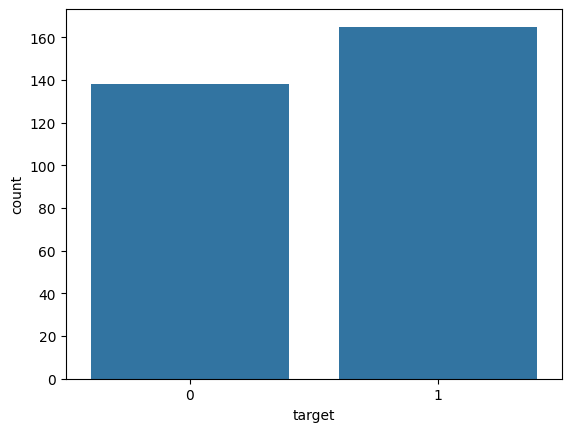

In [40]:
sns.countplot(data=df, x='target')

In [41]:
X = df.drop(['target'], axis=1)

In [42]:
y = df.target

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [45]:
pipe_rfecv = Pipeline([('scaler', StandardScaler()),
                 ('xgb', XGBClassifier())])

In [46]:
def get_xgb_importances(estimator):
    return estimator.named_steps['xgb'].feature_importances_

In [47]:
feature_selector = RFECV(
    estimator=pipe_rfecv, 
    cv=cv, 
    n_jobs=-1,
    importance_getter=get_xgb_importances 
).fit(X_train, y_train)

In [48]:
feature_selector.feature_names_in_

array(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype=object)

In [49]:
feature_selector.support_

array([False, False,  True, False, False, False, False, False,  True,
        True,  True,  True,  True])

In [50]:
feature_selector.feature_names_in_[feature_selector.support_]

array(['cp', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype=object)

In [51]:
feature_selector.ranking_

array([6, 2, 1, 3, 4, 8, 7, 5, 1, 1, 1, 1, 1])

In [69]:
scores = feature_selector.cv_results_['mean_test_score']
scores

array([0.75390244, 0.72426829, 0.75878049, 0.78353659, 0.78878049,
       0.80853659, 0.78402439, 0.79353659, 0.79853659, 0.79329268,
       0.79390244, 0.78390244, 0.77902439])

In [53]:
scores_df = pd.DataFrame({'Num Features': range(1, feature_selector.n_features_in_ + 1), 
                          'Mean Test Scores': scores})

In [70]:
scores_df

,Num Features,Mean Test Scores
0,1,0.753902
1,2,0.724268
2,3,0.758780
3,4,0.783537
4,5,0.788780
5,6,0.808537
6,7,0.784024
7,8,0.793537
8,9,0.798537
9,10,0.793293


In [54]:
optimal_features_count = feature_selector.n_features_

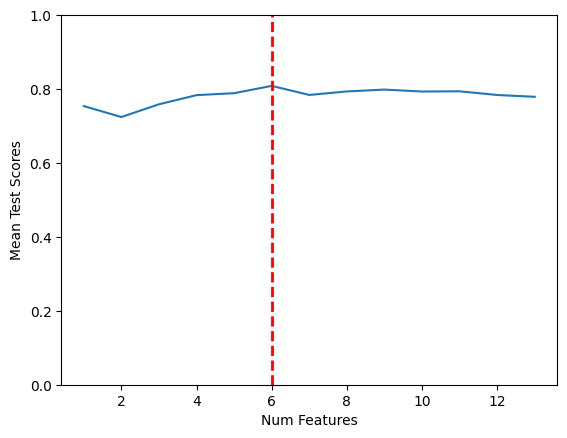

In [55]:
plt.figure()
sns.lineplot(data=scores_df, x='Num Features', y='Mean Test Scores')
plt.ylim(0,1)
plt.axvline(x=optimal_features_count, color='red', linestyle='--', linewidth=2)

In [56]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('estimator', RFE(estimator=XGBClassifier())),
                 ('model', XGBClassifier())])

In [57]:
pipe.set_params(estimator__n_features_to_select = feature_selector.n_features_)

,steps,"[('scaler', ...), ('estimator', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,"XGBClassifier...ree=None, ...)"
,n_features_to_select,np.int64(6)
,step,1
,verbose,0


In [58]:
parameters = {
    'model__n_estimators': [100, 200], 
    'model__learning_rate': [0.1, 0.2],
}

model = GridSearchCV(pipe, parameters, n_jobs=-1)
model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.1, 0.2], 'model__n_estimators': [100, 200]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [59]:
model.score(X_test, y_test)

0.81

In [60]:
model.best_estimator_

,steps,"[('scaler', ...), ('estimator', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,"XGBClassifier...ree=None, ...)"
,n_features_to_select,np.int64(6)
,step,1
,verbose,0


In [61]:
model.best_score_

np.float64(0.8279268292682926)

In [62]:
model.best_params_

{'model__learning_rate': 0.1, 'model__n_estimators': 100}

In [63]:
model.cv_results_['mean_test_score']

array([0.82792683, 0.82280488, 0.82280488, 0.81792683])

In [64]:
model.cv_results_['std_test_score']

array([0.05478094, 0.06034257, 0.07446378, 0.05840636])

In [65]:
predictions = model.predict(X_test)

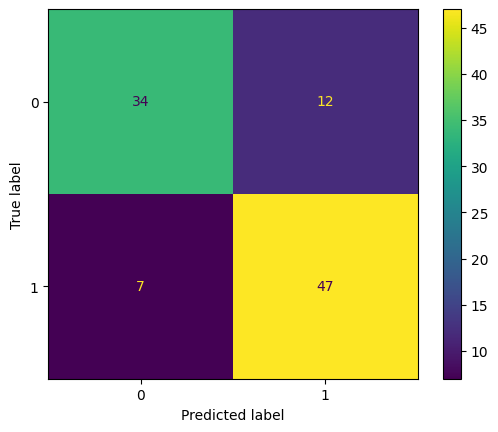

In [66]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()

In [67]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.74      0.78        46
           1       0.80      0.87      0.83        54

    accuracy                           0.81       100
   macro avg       0.81      0.80      0.81       100
weighted avg       0.81      0.81      0.81       100

